# Factory-to-Customer Shipping Route Efficiency Analysis for Nassau Candy Distributor

## Problem Statement

Nassau Candy Distributor operates as a national distributor, shipping products from multiple factories to customers across various US regions.

The objective of this project is to identify efficient and inefficient shipping routes, analyze shipping lead times, detect geographic bottlenecks, evaluate ship mode performance, and provide actionable recommendations for logistics optimization.

## Objectives

- Analyze shipping lead times
- Identify efficient and inefficient routes
- Evaluate ship mode performance
- Detect regional bottlenecks
- Build route efficiency KPIs
- Generate business recommendations

# Import Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

plt.style.use('ggplot')

# Load Dataset


In [2]:
df = pd.read_csv("/content/Nassau Candy Distributor.csv")

# Dataset Overview

In [3]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Country/Region,City,State/Province,Postal Code,Division,Region,Product ID,Product Name,Sales,Units,Gross Profit,Cost
0,1,US-2021-103800-CHO-MIL-31000,03-01-2024,30-06-2026,Standard Class,103800,United States,Houston,Texas,77095,Chocolate,Interior,CHO-MIL-31000,Wonka Bar - Milk Chocolate,6.50,2,4.22,2.28
1,2,US-2021-112326-CHO-TRI-54000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,7.50,2,4.90,2.60
2,3,US-2021-112326-CHO-NUT-13000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-NUT-13000,Wonka Bar - Nutty Crunch Surprise,10.47,3,7.47,3.00
3,4,US-2021-112326-CHO-SCR-58000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-SCR-58000,Wonka Bar -Scrumdiddlyumptious,10.80,3,7.50,3.30
4,5,US-2021-141817-CHO-TRI-54000,05-01-2024,05-07-2026,Standard Class,141817,United States,Philadelphia,Pennsylvania,19143,Chocolate,Atlantic,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,11.25,3,7.35,3.90


In [4]:
df.shape

(10194, 18)

In [5]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Country/Region', 'City', 'State/Province',
       'Postal Code', 'Division', 'Region', 'Product ID', 'Product Name',
       'Sales', 'Units', 'Gross Profit', 'Cost'],
      dtype='object')

In [6]:
df.describe()

,Row ID,Customer ID,Sales,Units,Gross Profit,Cost
count,10194.000000,10194.000000,10194.000000,10194.000000,10194.000000,10194.000000
mean,5097.500000,134468.961154,13.908537,3.791838,9.166451,4.742087
std,2942.898656,20231.483007,11.341020,2.228317,6.643740,5.061647
min,1.000000,100006.000000,1.250000,1.000000,0.250000,0.600000
25%,2549.250000,117212.000000,7.200000,2.000000,4.900000,2.400000
50%,5097.500000,133550.000000,10.800000,3.000000,7.470000,3.600000
75%,7645.750000,152051.000000,18.000000,5.000000,12.250000,5.700000
max,10194.000000,192314.000000,260.000000,14.000000,130.000000,130.000000


In [7]:
df.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Country/Region,0
City,0
State/Province,0
Postal Code,0


# Checking Missing values



In [8]:
missing = df.isnull().sum()

missing[missing > 0]

,0


# Checking Duplicate Records

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.drop_duplicates(inplace=True)

In [11]:
df[['Order Date','Ship Date']].head()

,Order Date,Ship Date
0,03-01-2024,30-06-2026
1,04-01-2024,01-07-2026
2,04-01-2024,01-07-2026
3,04-01-2024,01-07-2026
4,05-01-2024,05-07-2026


In [15]:
df['Order Date'] = pd.to_datetime(
    df['Order Date'],
    dayfirst=True
)

df['Ship Date'] = pd.to_datetime(
    df['Ship Date'],
    dayfirst=True
)

In [16]:
df[['Order Date','Ship Date']].head()

,Order Date,Ship Date
0,2024-01-03,2026-06-30
1,2024-01-04,2026-07-01
2,2024-01-04,2026-07-01
3,2024-01-04,2026-07-01
4,2024-01-05,2026-07-05


In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10194 entries, 0 to 10193
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Row ID          10194 non-null  int64         
 1   Order ID        10194 non-null  object        
 2   Order Date      10194 non-null  datetime64[ns]
 3   Ship Date       10194 non-null  datetime64[ns]
 4   Ship Mode       10194 non-null  object        
 5   Customer ID     10194 non-null  int64         
 6   Country/Region  10194 non-null  object        
 7   City            10194 non-null  object        
 8   State/Province  10194 non-null  object        
 9   Postal Code     10194 non-null  object        
 10  Division        10194 non-null  object        
 11  Region          10194 non-null  object        
 12  Product ID      10194 non-null  object        
 13  Product Name    10194 non-null  object        
 14  Sales           10194 non-null  float64       
 15  Un

In [19]:
factory_map = {

"Wonka Bar - Nutty Crunch Surprise":"Lot's O' Nuts",
"Wonka Bar - Fudge Mallows":"Lot's O' Nuts",
"Wonka Bar -Scrumdiddlyumptious":"Lot's O' Nuts",

"Wonka Bar - Milk Chocolate":"Wicked Choccy's",
"Wonka Bar - Triple Dazzle Caramel":"Wicked Choccy's",

"Laffy Taffy":"Sugar Shack",
"SweeTARTS":"Sugar Shack",
"Nerds":"Sugar Shack",
"Fun Dip":"Sugar Shack",
"Fizzy Lifting Drinks":"Sugar Shack",

"Everlasting Gobstopper":"Secret Factory",

"Hair Toffee":"The Other Factory",

"Lickable Wallpaper":"Secret Factory",
"Wonka Gum":"Secret Factory",

"Kazookles":"The Other Factory"

}

# Creating Factory Mapping

In [20]:
df['Factory'] = df['Product Name'].map(factory_map)

In [21]:
df[['Product Name','Factory']].head(20)

,Product Name,Factory
0,Wonka Bar - Milk Chocolate,Wicked Choccy's
1,Wonka Bar - Triple Dazzle Caramel,Wicked Choccy's
2,Wonka Bar - Nutty Crunch Surprise,Lot's O' Nuts
3,Wonka Bar -Scrumdiddlyumptious,Lot's O' Nuts
4,Wonka Bar - Triple Dazzle Caramel,Wicked Choccy's
5,Wonka Bar -Scrumdiddlyumptious,Lot's O' Nuts
6,Wonka Bar - Triple Dazzle Caramel,Wicked Choccy's
7,Wonka Bar - Milk Chocolate,Wicked Choccy's
8,Wonka Bar - Nutty Crunch Surprise,Lot's O' Nuts
9,Wonka Bar - Milk Chocolate,Wicked Choccy's


# Creating Lead Time

In [22]:
df['Lead Time'] = (
    df['Ship Date'] -
    df['Order Date']
).dt.days

In [23]:
df[['Order Date','Ship Date','Lead Time']].head()

,Order Date,Ship Date,Lead Time
0,2024-01-03,2026-06-30,909
1,2024-01-04,2026-07-01,909
2,2024-01-04,2026-07-01,909
3,2024-01-04,2026-07-01,909
4,2024-01-05,2026-07-05,912


# Validating Lead Time

In [24]:
df['Lead Time'].describe()

,Lead Time
count,10194.000000
mean,1320.841868
std,262.444892
min,904.000000
25%,1271.000000
50%,1274.000000
75%,1638.000000
max,1642.000000


In [25]:
df[df['Lead Time'] < 0]

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Country/Region,City,State/Province,Postal Code,Division,Region,Product ID,Product Name,Sales,Units,Gross Profit,Cost,Factory,Lead Time


In [26]:
df[['Order Date','Ship Date','Lead Time']].sample(10)

,Order Date,Ship Date,Lead Time
6481,2025-12-02,2029-05-29,1274
4578,2025-04-08,2028-10-02,1273
1505,2024-11-07,2027-05-04,908
1979,2024-12-27,2027-06-25,910
4359,2025-03-01,2028-08-25,1273
4369,2025-03-03,2028-08-28,1274
3721,2024-11-20,2028-05-18,1275
4058,2024-12-18,2028-06-14,1274
4719,2025-05-03,2028-10-25,1271
8624,2025-09-09,2030-03-07,1640


In [27]:
print(df['Order Date'].min())
print(df['Order Date'].max())

print(df['Ship Date'].min())
print(df['Ship Date'].max())

2024-01-02 00:00:00
2025-12-31 00:00:00
2026-06-30 00:00:00
2030-06-28 00:00:00


# Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) is performed to understand the characteristics of the dataset, identify patterns, detect anomalies, and uncover relationships between variables.

In this project, EDA focuses on understanding shipping lead times, shipment distribution across regions, ship mode performance, sales trends, and geographic patterns. These insights provide the foundation for route efficiency analysis and logistics optimization.

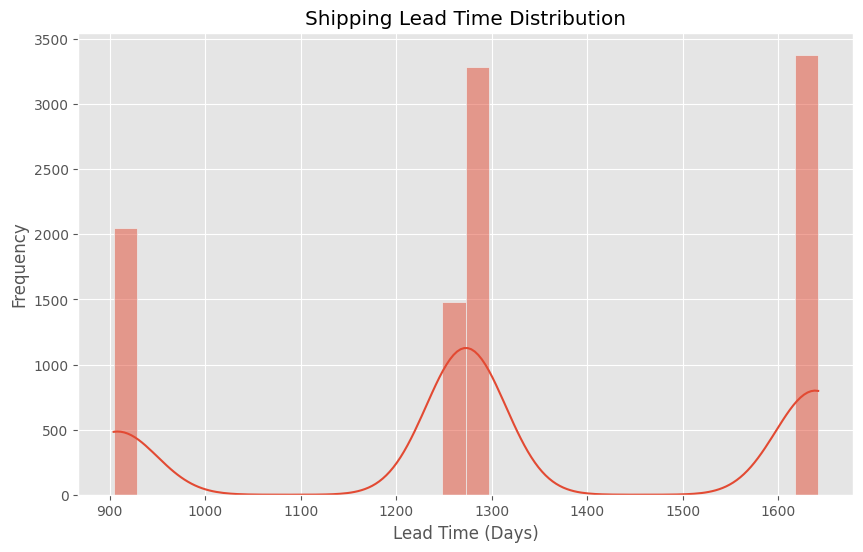

In [28]:
plt.figure(figsize=(10,6))

sns.histplot(
    df['Lead Time'],
    bins=30,
    kde=True
)

plt.title('Shipping Lead Time Distribution')
plt.xlabel('Lead Time (Days)')
plt.ylabel('Frequency')

plt.show()

## Shipping Lead Time Distribution

Shipping Lead Time represents the number of days between the order date and shipment date.

Analyzing the distribution of lead times helps identify:
- Typical shipment durations
- Variability in delivery performance
- Potential outliers and delays

Understanding lead time distribution is essential for evaluating route efficiency and service reliability.

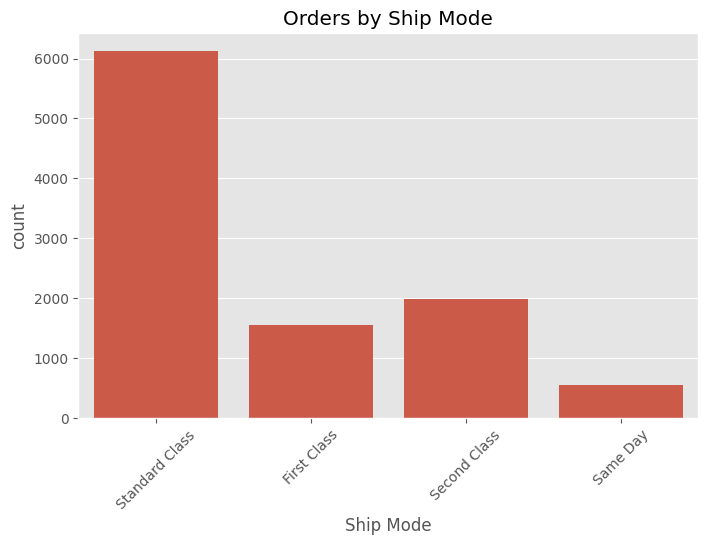

In [29]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='Ship Mode',
    data=df
)

plt.xticks(rotation=45)

plt.title('Orders by Ship Mode')

plt.show()

## Ship Mode Distribution

Different shipping methods are used to transport products to customers.

This analysis examines:
- The popularity of each shipping mode
- Shipment volume distribution across shipping methods

Understanding ship mode usage helps evaluate operational preferences and resource allocation.

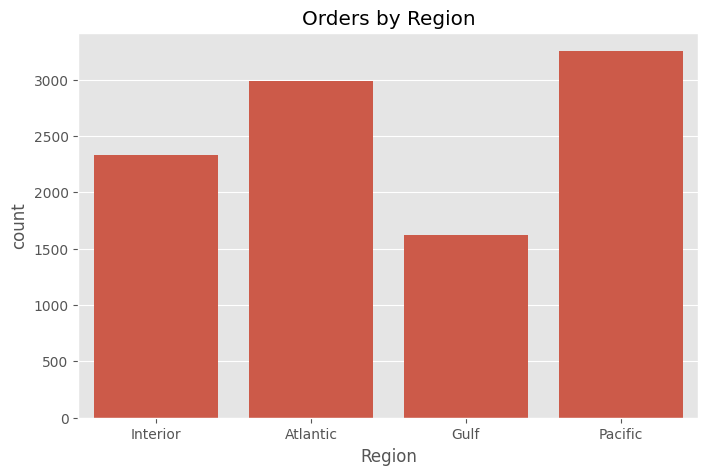

In [30]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='Region',
    data=df
)

plt.title('Orders by Region')

plt.show()

## Regional Order Distribution

This analysis examines how orders are distributed across different regions.

The objective is to identify:
- High-demand regions
- Regional shipment concentration
- Areas requiring greater logistics support

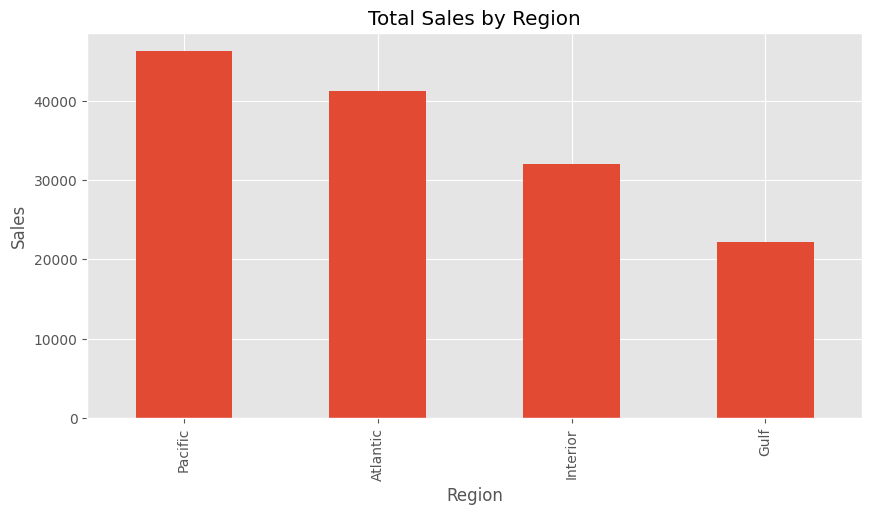

In [31]:
sales_region = (
    df.groupby('Region')['Sales']
    .sum()
    .sort_values(ascending=False)
)

sales_region.plot(
    kind='bar',
    figsize=(10,5)
)

plt.title('Total Sales by Region')
plt.ylabel('Sales')

plt.show()

## Total Sales by Region

Sales performance is analyzed across regions to understand revenue contribution.

This analysis helps identify:
- Top revenue-generating regions
- Market concentration
- Regional business opportunities

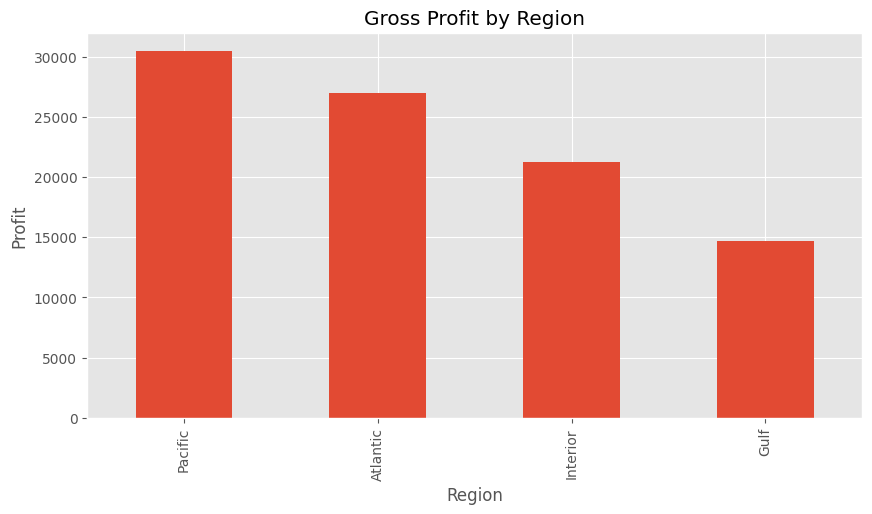

In [32]:
profit_region = (
    df.groupby('Region')['Gross Profit']
    .sum()
    .sort_values(ascending=False)
)

profit_region.plot(
    kind='bar',
    figsize=(10,5)
)

plt.title('Gross Profit by Region')
plt.ylabel('Profit')

plt.show()

## Gross Profit by Region

Gross profit provides insight into regional profitability.

This analysis helps determine:
- Most profitable regions
- Financial contribution by geography
- Potential areas for expansion

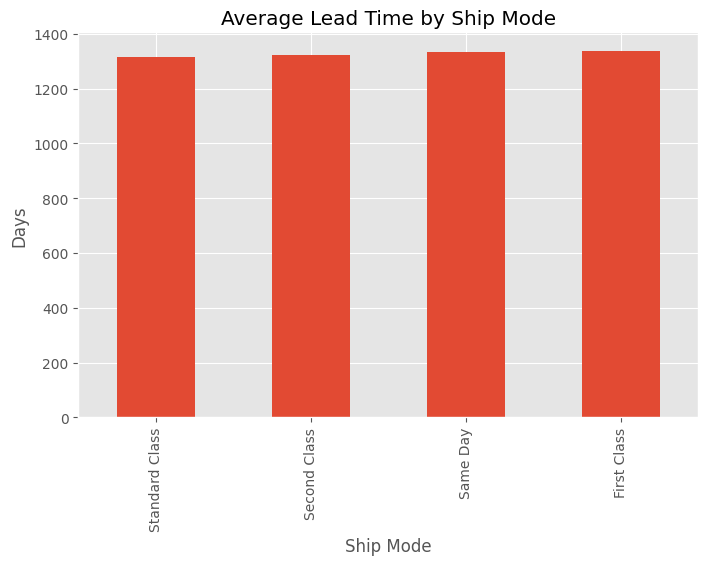

In [33]:
ship_mode_perf = (
    df.groupby('Ship Mode')
    ['Lead Time']
    .mean()
    .sort_values()
)

ship_mode_perf.plot(
    kind='bar',
    figsize=(8,5)
)

plt.title('Average Lead Time by Ship Mode')
plt.ylabel('Days')

plt.show()

## Average Lead Time by Ship Mode

Shipping methods influence delivery speed.

This analysis compares:
- Average shipment duration across shipping methods
- Relative efficiency of available shipping modes

The results help evaluate service performance and operational effectiveness.

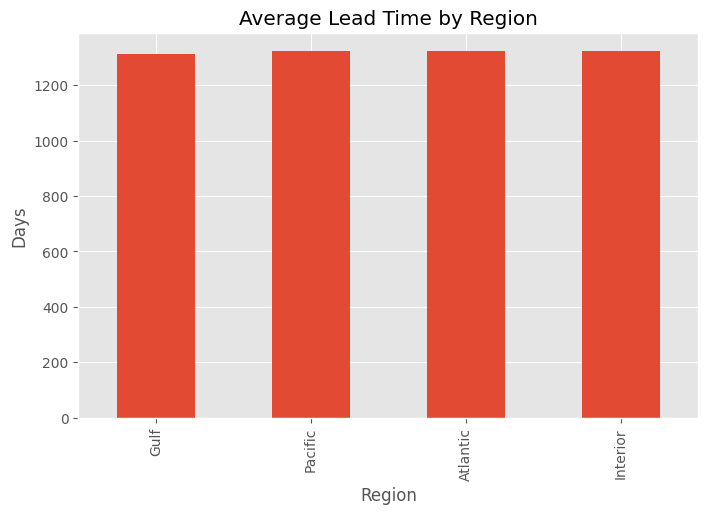

In [34]:
region_perf = (
    df.groupby('Region')
    ['Lead Time']
    .mean()
    .sort_values()
)

region_perf.plot(
    kind='bar',
    figsize=(8,5)
)

plt.title('Average Lead Time by Region')
plt.ylabel('Days')

plt.show()

## Average Lead Time by Region

Regional performance may vary because of geographic distance, logistics infrastructure, and shipment volume.

This analysis identifies:
- Fastest regions
- Slowest regions
- Areas requiring logistics improvements

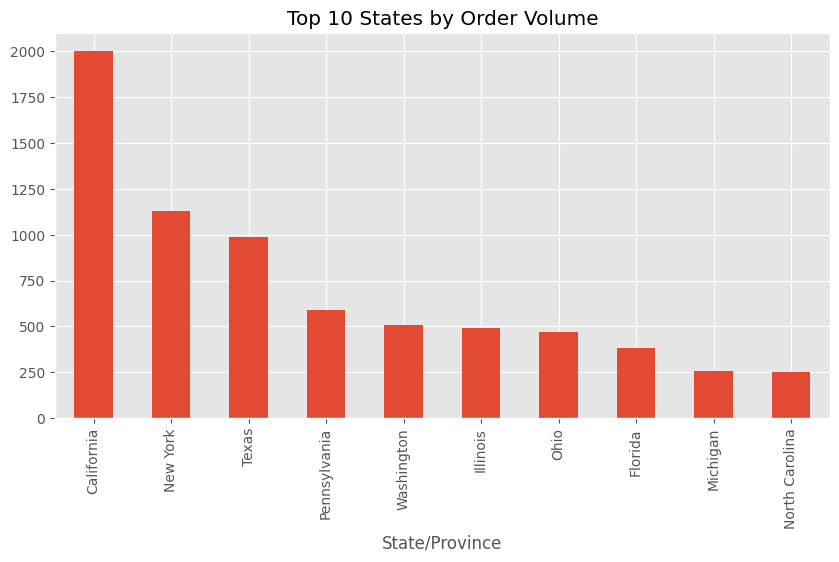

In [35]:
top_states = (
    df['State/Province']
    .value_counts()
    .head(10)
)

top_states.plot(
    kind='bar',
    figsize=(10,5)
)

plt.title('Top 10 States by Order Volume')

plt.show()

## Top 10 States by Order Volume

Order volume analysis helps identify key customer markets.

This analysis highlights:
- States generating the highest shipment demand
- Geographic concentration of customers
- Regions requiring increased logistics resources

# Route Efficiency Analysis

The primary objective of this project is to evaluate factory-to-customer shipping routes.

Route efficiency analysis helps identify:
- High-performing routes
- Underperforming routes
- Delivery bottlenecks
- Opportunities for logistics optimization

Each route is defined as:

Factory → Customer State

## Route Definition

To evaluate logistics performance, routes are created by combining factory locations with customer destinations.

This enables shipment performance analysis at the route level.

In [36]:
df['Factory_State_Route'] = (
    df['Factory'] + ' → ' +
    df['State/Province']
)

df['Factory_Region_Route'] = (
    df['Factory'] + ' → ' +
    df['Region']
)

## Delay Analysis

A delay flag is created to classify shipments as delayed or non-delayed.

Shipments exceeding the average lead time are considered delayed.

This metric is later used to calculate delay frequency and identify operational bottlenecks.

In [37]:
lead_threshold = df['Lead Time'].mean()

df['Delayed'] = np.where(
    df['Lead Time'] > lead_threshold,
    1,
    0
)

## Route Performance Summary

For each route, the following metrics are calculated:

- Total Shipments
- Average Lead Time
- Lead Time Variability

These metrics provide a comprehensive view of route performance.

In [38]:
route_summary = (

df.groupby('Factory_State_Route')

.agg(
Total_Shipments=('Order ID','count'),
Average_Lead_Time=('Lead Time','mean'),
Lead_Time_STD=('Lead Time','std')
)

.reset_index()

)

route_summary.head()

,Factory_State_Route,Total_Shipments,Average_Lead_Time,Lead_Time_STD
0,Lot's O' Nuts → Alabama,34,1295.205882,253.070332
1,Lot's O' Nuts → Alberta,16,1273.875000,266.924428
2,Lot's O' Nuts → Arizona,111,1306.198198,253.901155
3,Lot's O' Nuts → Arkansas,31,1285.354839,274.529118
4,Lot's O' Nuts → British Columbia,18,1273.777778,307.082774


## Route Efficiency Score

A normalized efficiency score is created to compare route performance.

Lower average lead times result in higher efficiency scores.

This enables route ranking and benchmarking.

In [40]:
max_time = route_summary[
    'Average_Lead_Time'
].max()

route_summary[
    'Efficiency_Score'
] = (

100 -

(
route_summary[
'Average_Lead_Time'
]
/
max_time
*100
)

)

## Top 10 Most Efficient Routes

Routes with the lowest average lead times are identified as the most efficient.

These routes represent logistics best practices and may serve as benchmarks for improvement initiatives.

## Bottom 10 Least Efficient Routes

Routes with the highest average lead times are identified as the least efficient.

These routes require further investigation to determine the causes of poor performance.

## Delay Frequency Analysis

Delay frequency measures the percentage of shipments classified as delayed.

This KPI provides an overall assessment of logistics performance and delivery reliability.

## Route Volume Analysis

Shipment volume is analyzed to identify the busiest routes.

Routes with both high shipment volume and poor performance may represent significant operational bottlenecks.

# Geographic Bottleneck Analysis

Geographic bottleneck analysis helps identify regions and states experiencing poor shipping performance.

The objective is to detect:

- High average lead time regions
- High shipment volume regions with poor performance
- States that may require logistics optimization

These insights help improve delivery efficiency and operational planning.

## State-Level Performance Analysis

This analysis evaluates average lead time and shipment volume for each state.

States with both high shipment volume and high lead time may represent operational bottlenecks.

In [41]:
state_perf = (

df.groupby('State/Province')

.agg(
Average_Lead_Time=('Lead Time','mean'),
Shipments=('Order ID','count')
)

.reset_index()

)

state_perf.head()

,State/Province,Average_Lead_Time,Shipments
0,Alabama,1291.278689,61
1,Alberta,1274.076923,26
2,Arizona,1309.214286,224
3,Arkansas,1285.733333,60
4,British Columbia,1290.318182,22


## Top Bottleneck States

States with the highest average lead times are identified as bottleneck locations.

These areas may require process improvements or route optimization.

In [42]:
bottlenecks = (

state_perf

.sort_values(
'Average_Lead_Time',
ascending=False
)

.head(10)

)

bottlenecks

,State/Province,Average_Lead_Time,Shipments
56,West Virginia,1638.000000,4
37,North Dakota,1637.857143,7
47,Saskatchewan,1457.000000,2
20,Manitoba,1455.333333,12
15,Iowa,1443.900000,30
33,New Mexico,1441.837838,37
53,Vermont,1438.909091,11
44,Prince Edward Island,1420.300000,10
49,South Dakota,1395.916667,12
50,Tennessee,1391.486339,183


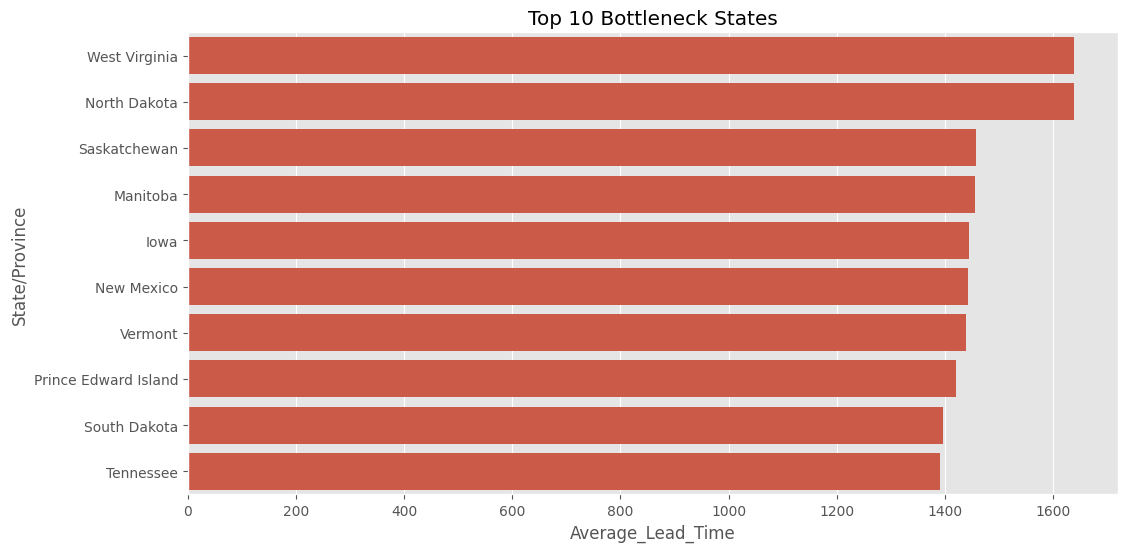

In [43]:
plt.figure(figsize=(12,6))

sns.barplot(
data=bottlenecks,
x='Average_Lead_Time',
y='State/Province'
)

plt.title('Top 10 Bottleneck States')

plt.show()

## Regional Bottleneck Analysis

This analysis compares average lead time across regions to identify geographic areas experiencing slower shipping performance.

In [44]:
region_bottlenecks = (

df.groupby('Region')

.agg(
Average_Lead_Time=('Lead Time','mean'),
Shipments=('Order ID','count')
)

.reset_index()

)

region_bottlenecks

,Region,Average_Lead_Time,Shipments
0,Atlantic,1322.745144,2986
1,Gulf,1311.374691,1620
2,Interior,1323.091221,2335
3,Pacific,1322.194897,3253


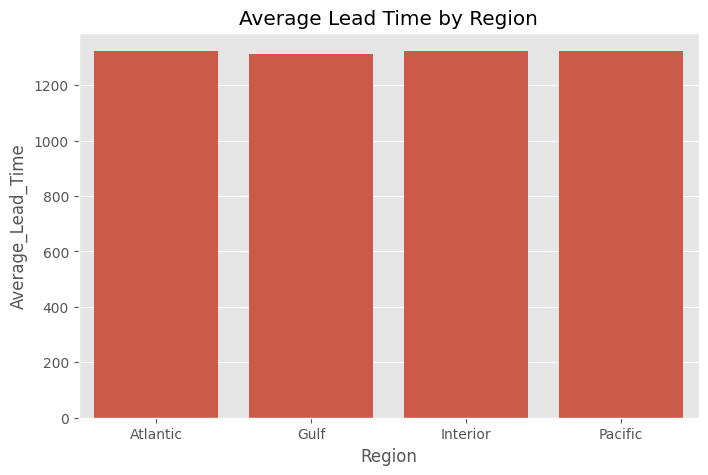

In [45]:
plt.figure(figsize=(8,5))

sns.barplot(
data=region_bottlenecks,
x='Region',
y='Average_Lead_Time'
)

plt.title('Average Lead Time by Region')

plt.show()

# Key Performance Indicators (KPIs)

Key Performance Indicators provide a high-level summary of logistics performance.

The following KPIs are calculated:

- Average Lead Time
- Total Orders
- Total Sales
- Total Gross Profit
- Delay Frequency
- Route Efficiency

In [46]:
avg_lead_time = df['Lead Time'].mean()

total_orders = len(df)

total_sales = df['Sales'].sum()

total_profit = df['Gross Profit'].sum()

delay_rate = (
df['Delayed'].mean()
*100
)

print("Average Lead Time:", round(avg_lead_time,2))

print("Total Orders:", total_orders)

print("Total Sales:", round(total_sales,2))

print("Total Gross Profit:", round(total_profit,2))

print("Delay Frequency:", round(delay_rate,2))

Average Lead Time: 1320.84
Total Orders: 10194
Total Sales: 141783.63
Total Gross Profit: 93442.8
Delay Frequency: 33.15


# Correlation Analysis

Correlation analysis helps identify relationships between key business variables such as sales, units sold, profit, cost, and lead time.

This analysis provides insights into factors that may influence shipping performance and profitability.

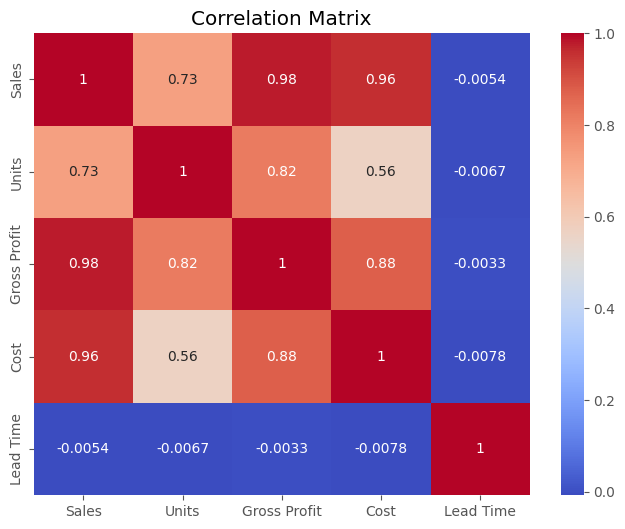

In [47]:
numeric_cols = [

'Sales',
'Units',
'Gross Profit',
'Cost',
'Lead Time'

]

corr = (
df[numeric_cols]
.corr()
)

plt.figure(figsize=(8,6))

sns.heatmap(
corr,
annot=True,
cmap='coolwarm'
)

plt.title('Correlation Matrix')

plt.show()

# Recommendations

Based on the analysis, the following recommendations are proposed:

1. Prioritize high-performing routes as operational benchmarks.

2. Investigate routes with consistently high lead times to identify causes of delay.

3. Optimize logistics operations in bottleneck states and regions.

4. Promote efficient shipping modes where appropriate.

5. Continuously monitor route performance using real-time dashboards.

6. Implement route-level performance tracking to improve delivery reliability.

# Conclusion

This project successfully analyzed factory-to-customer shipping routes for Nassau Candy Distributor.

The analysis identified route efficiency patterns, regional bottlenecks, shipping mode performance differences, and key logistics KPIs.

The findings provide actionable insights that can support data-driven logistics optimization, reduce delays, improve customer satisfaction, and enhance nationwide delivery performance.